# iBAQ per tissue — FragPipe (Banana)

Compute **iBAQ** (intensity-Based Absolute Quantification) for each protein in each of the 23
banana tissues:

$$\text{iBAQ}(\text{protein}, \text{tissue}) = \frac{\text{Total Intensity}(\text{protein}, \text{tissue})}{N_\text{observable peptides}(\text{protein})}$$

- **Numerator** — the `Total Intensity` column of each tissue's `protein.tsv`.
- **Denominator** — number of theoretically observable tryptic peptides per protein: fully cleaved
  (0 missed cleavages), length 6–30 aa, using the **stricttrypsin** rule (cut after every K/R,
  including before proline) to match the FragPipe search. Depends only on sequence, so computed once.
- **Protein universe** — only proteins actually **detected in `combined_protein.tsv`**
  (`rev_` decoys dropped, contaminants kept), not the full FASTA.

Tissue columns are labelled by sample-folder ID (`P0871xx_n`); human-readable tissue names are not
present in the search outputs.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_DIR = Path(
    "/cmnfs/ENB/search_results/FinalFragger/Banana/FragPipeSearchResults"
)
OUT_PATH = Path("ibaq_tissues.tsv")  # written next to this notebook

# Observable-peptide parameters (iBAQ denominator).
MIN_LEN, MAX_LEN = 6, 30   # keep tryptic peptides in this length range (inclusive)
UNIQUE = False             # False = count all peptides (original iBAQ); True = dedupe

# Resolve the search FASTA from the FragPipe params so it always matches the results.
params = (RESULTS_DIR / "fragger_dda_plus.params").read_text()
FASTA_PATH = Path(re.search(r"database_name\s*=\s*(\S+)", params).group(1))
print("FASTA:", FASTA_PATH, "| exists:", FASTA_PATH.exists())

FASTA: /cmnfs/ENB/temp/FinalFragger/Banana/f4/a359c3bec11b9fd4c2889107570c5b/2026-02-10-decoys-contam-Musa_x_paradisiaca.helixer.faa.fas | exists: True


In [2]:
# Detected proteins: the identified set from combined_protein.tsv (drop rev_ decoys).
# We key on the full "Protein" header form (e.g. "sp|O77727|K1C15_SHEEP"), which matches
# both the FASTA headers and the "Protein" column of the per-tissue protein.tsv files.
combined = pd.read_csv(
    RESULTS_DIR / "combined_protein.tsv", sep="\t", low_memory=False,
    usecols=["Protein"],
)
detected = set(combined.loc[~combined["Protein"].str.startswith("rev_"), "Protein"])
print(f"Detected proteins (non-decoy): {len(detected)}")

Detected proteins (non-decoy): 19039


In [3]:
# In-silico digestion -> observable-peptide count (iBAQ denominator).
def read_fasta(path, keep):
    """Yield {header_id: sequence} for entries whose id is in `keep`."""
    seqs, pid, buf = {}, None, []
    with open(path) as fh:
        for line in fh:
            if line.startswith(">"):
                if pid in keep:
                    seqs[pid] = "".join(buf)
                pid = line[1:].strip().split()[0]
                buf = []
            else:
                buf.append(line.strip())
    if pid in keep:
        seqs[pid] = "".join(buf)
    return seqs


def digest_strict(seq):
    """Strict tryptic digest: cut C-terminal to every K/R (including before proline)."""
    cuts = [i + 1 for i, aa in enumerate(seq) if aa in "KR"]
    bounds = [0, *cuts, len(seq)]
    return [seq[bounds[i]:bounds[i + 1]] for i in range(len(bounds) - 1)]


def n_observable(seq, lo=MIN_LEN, hi=MAX_LEN, unique=UNIQUE):
    peps = [p for p in digest_strict(seq) if lo <= len(p) <= hi]
    return len(set(peps)) if unique else len(peps)


seqs = read_fasta(FASTA_PATH, detected)
print(f"Sequences matched: {len(seqs)} / {len(detected)}")

# Observable peptide count per protein; 0 -> NaN so iBAQ never divides by zero.
pep_counts = pd.Series({pid: n_observable(s) for pid, s in seqs.items()}, name="n_observable")
pep_counts_nz = pep_counts.replace(0, np.nan)
print(f"Proteins with 0 observable peptides: {int((pep_counts == 0).sum())}")
pep_counts.describe()

Sequences matched: 19039 / 19039
Proteins with 0 observable peptides: 0


count    19039.000000
mean        27.728820
std         20.283482
min          1.000000
25%         15.000000
50%         23.000000
75%         35.000000
max        407.000000
Name: n_observable, dtype: float64

In [4]:
# Per-tissue Total Intensity -> proteins x tissues matrix (numerator).
frames = {}
for tsv in sorted(RESULTS_DIR.glob("P08*/protein.tsv")):
    tissue = tsv.parent.name
    d = pd.read_csv(tsv, sep="\t", low_memory=False, usecols=["Protein", "Total Intensity"])
    frames[tissue] = d.set_index("Protein")["Total Intensity"]

# Reindex to the detected-protein universe (proteins absent in a tissue become NaN).
intensity = pd.DataFrame(frames).reindex(sorted(detected))
print(f"Intensity matrix: {intensity.shape[0]} proteins x {intensity.shape[1]} tissues")
intensity.head()

Intensity matrix: 19039 proteins x 23 tissues


,P087149_1,P087150_2,P087151_3,P087152_4,P087153_5,P087154_6,P087155_7,P087156_8,P087157_9,P087158_10,...,P087162_14,P087163_15,P087164_16,P087165_17,P087166_18,P087167_19,P087168_20,P087169_21,P087170_22,P087171_23
Protein,,,,,,,,,,,,,,,,,,,,,
GWHCAXY00000001_000001.1,11199309.0,NaN,NaN,NaN,2300308.8,NaN,7.075530e+06,19328320.0,2470938.5,29807240.0,...,NaN,NaN,8.961423e+06,NaN,5657122.0,36724196.0,1159383.1,NaN,NaN,NaN
GWHCAXY00000001_000005.1,0.0,NaN,NaN,NaN,4792755.5,NaN,4.937690e+06,NaN,NaN,4588564.0,...,NaN,NaN,NaN,NaN,NaN,11612432.0,NaN,NaN,NaN,NaN
GWHCAXY00000001_000006.1,531700500.0,1.077168e+09,793761000.0,580819800.0,202591120.0,1.835519e+07,1.004556e+09,174977780.0,418007680.0,977473340.0,...,7274539.0,3.769304e+08,5.273006e+08,70819656.0,206546400.0,90055430.0,77744730.0,16428699.0,7400974.5,762410560.0
GWHCAXY00000001_000010.1,0.0,NaN,NaN,NaN,0.0,0.000000e+00,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,27169316.0,48224824.0,NaN,NaN,11805535.0,NaN
GWHCAXY00000001_000013.1,411585340.0,3.723925e+08,328148540.0,610332700.0,343123520.0,1.014995e+09,5.772636e+08,290146880.0,267745380.0,290479140.0,...,98467890.0,2.287338e+09,2.504900e+09,110025360.0,313164830.0,165164400.0,43355390.0,2058166.6,39009704.0,185371360.0


In [5]:
# iBAQ = Total Intensity / observable-peptide count, then save.
ibaq = intensity.div(pep_counts_nz.reindex(intensity.index), axis=0)

ibaq.to_csv(OUT_PATH, sep="\t")
print(f"iBAQ matrix: {ibaq.shape[0]} proteins x {ibaq.shape[1]} tissues")
print(f"Contains inf: {np.isinf(ibaq.to_numpy()).any()}  ->  saved to {OUT_PATH.resolve()}")
ibaq.head()

iBAQ matrix: 19039 proteins x 23 tissues
Contains inf: False  ->  saved to /cmnfs/home/c.saylan/Projects/ENB/cross_species_framework_ENB/nbs/ibaq_tissues.tsv


,P087149_1,P087150_2,P087151_3,P087152_4,P087153_5,P087154_6,P087155_7,P087156_8,P087157_9,P087158_10,...,P087162_14,P087163_15,P087164_16,P087165_17,P087166_18,P087167_19,P087168_20,P087169_21,P087170_22,P087171_23
Protein,,,,,,,,,,,,,,,,,,,,,
GWHCAXY00000001_000001.1,3.293914e+05,NaN,NaN,NaN,6.765614e+04,NaN,2.081038e+05,5.684800e+05,7.267466e+04,8.766835e+05,...,NaN,NaN,2.635713e+05,NaN,1.663859e+05,1.080123e+06,3.409950e+04,NaN,NaN,NaN
GWHCAXY00000001_000005.1,0.000000e+00,NaN,NaN,NaN,1.198189e+05,NaN,1.234423e+05,NaN,NaN,1.147141e+05,...,NaN,NaN,NaN,NaN,NaN,2.903108e+05,NaN,NaN,NaN,NaN
GWHCAXY00000001_000006.1,1.329251e+07,2.692919e+07,1.984402e+07,1.452050e+07,5.064778e+06,4.588798e+05,2.511390e+07,4.374444e+06,1.045019e+07,2.443683e+07,...,1.818635e+05,9.423261e+06,1.318252e+07,1.770491e+06,5.163660e+06,2.251386e+06,1.943618e+06,410717.475000,1.850244e+05,1.906026e+07
GWHCAXY00000001_000010.1,0.000000e+00,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,0.000000e+00,...,NaN,NaN,NaN,NaN,1.811288e+06,3.214988e+06,NaN,NaN,7.870357e+05,NaN
GWHCAXY00000001_000013.1,1.112393e+07,1.006466e+07,8.868879e+06,1.649548e+07,9.273609e+06,2.743231e+07,1.560172e+07,7.841808e+06,7.236362e+06,7.850788e+06,...,2.661294e+06,6.181996e+07,6.770000e+07,2.973658e+06,8.463914e+06,4.463903e+06,1.171767e+06,55626.124324,1.054316e+06,5.010037e+06


In [6]:
# Sanity checks.
# 1) Hand-verify one protein: iBAQ == Total Intensity / observable peptide count.
p = "GWHCAXY00000001_000006.1"
peps = [x for x in digest_strict(seqs[p]) if MIN_LEN <= len(x) <= MAX_LEN]
t = ibaq.columns[0]
print(f"{p}: length={len(seqs[p])}, observable peptides={len(peps)}")
print(f"  {t}: intensity={intensity.loc[p, t]:.4e}  ibaq={ibaq.loc[p, t]:.4e}  "
      f"expected={intensity.loc[p, t] / len(peps):.4e}")

# 2) Proteins with a non-zero iBAQ per tissue (i.e. quantified in that tissue).
print("\nQuantified proteins per tissue:")
print((ibaq > 0).sum())

GWHCAXY00000001_000006.1: length=776, observable peptides=40
  P087149_1: intensity=5.3170e+08  ibaq=1.3293e+07  expected=1.3293e+07

Quantified proteins per tissue:
P087149_1     14535
P087150_2     14289
P087151_3     12820
P087152_4     12510
P087153_5     14987
P087154_6     12463
P087155_7     15639
P087156_8     15069
P087157_9     13880
P087158_10    14989
P087159_11    12749
P087160_12    13643
P087161_13     7982
P087162_14     8430
P087163_15    13195
P087164_16    13597
P087165_17    13170
P087166_18    14895
P087167_19    15770
P087168_20    11859
P087169_21     6407
P087170_22    12167
P087171_23    12387
dtype: int64


## Cross-check against `combined_peptide.tsv` intensities

The iBAQ above uses `protein.tsv` **Total Intensity** as the numerator. FragPipe also reports a
per-sample peptide-level intensity in `combined_peptide.tsv` (`[sample] Intensity`). Summing those
peptide intensities per protein gives an alternative numerator (this equals the `[sample] Intensity`
column of `combined_protein.tsv`). Dividing by the same observable-peptide count yields a second
iBAQ estimate. Both share the denominator, so this compares the two intensity definitions.

In [57]:
# Alternative iBAQ from combined_protein.tsv: sum [sample] Intensity per protein, / peptide count.
pro_int_cols = [f"{t} Intensity" for t in ibaq.columns]
# pro_int_cols = [f"{t} MaxLFQ Intensity" for t in ibaq.columns]

In [59]:
proteins = pd.read_csv(
    RESULTS_DIR / "combined_protein.tsv", sep="\t", low_memory=False,
    usecols=["Protein", *pro_int_cols],
)
pro_intensity = proteins.groupby("Protein")[pro_int_cols].sum()
pro_intensity.columns = ibaq.columns  # strip " Intensity" suffix -> tissue ids
pro_intensity = pro_intensity.reindex(ibaq.index)

ibaq_pro = pro_intensity.copy()

# Per-tissue agreement between the two iBAQ estimates (proteins quantified by both).
from scipy.stats import pearsonr, spearmanr

rows = []
for t in ibaq.columns:
    both = pd.DataFrame({"a": ibaq[t], "b": ibaq_pro[t]})
    both = both[(both["a"] > 0) & (both["b"] > 0)].dropna()
    la, lb = np.log2(both["a"]), np.log2(both["b"])
    rows.append({
        "tissue": t,
        "n": len(both),
        "pearson_log2": pearsonr(la, lb)[0],
        "spearman": spearmanr(both["a"], both["b"])[0],
        "median_ratio_pep/prot": (both["b"] / both["a"]).median(),
    })
agreement = pd.DataFrame(rows).set_index("tissue")
print(agreement.round(3))
print("\nAcross all tissues — mean pearson(log2): "
      f"{agreement['pearson_log2'].mean():.3f}, mean spearman: {agreement['spearman'].mean():.3f}")

                n  pearson_log2  spearman  median_ratio_pep/prot
tissue                                                          
P087149_1   12267         0.603     0.589                 98.193
P087150_2   11962         0.597     0.583                103.825
P087151_3   10293         0.593     0.578                148.224
P087152_4    9986         0.578     0.564                142.318
P087153_5   12535         0.592     0.573                114.753
P087154_6    9741         0.635     0.614                 59.792
P087155_7   13372         0.575     0.563                123.692
P087156_8   12687         0.577     0.565                 98.216
P087157_9   11349         0.599     0.585                113.783
P087158_10  12653         0.588     0.573                114.570
P087159_11  10227         0.603     0.591                119.210
P087160_12  11174         0.591     0.577                118.329
P087161_13   5407         0.622     0.615                194.564
P087162_14   6015        

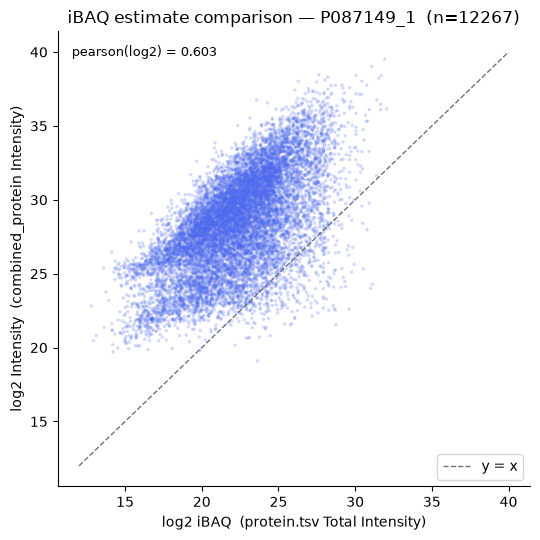

In [61]:
# Scatter: protein.tsv-based iBAQ vs combined_protein-based iBAQ (log-log), one tissue.
import matplotlib.pyplot as plt

t = ibaq.columns[0]
both = pd.DataFrame({"prot": ibaq[t], "pep": ibaq_pro[t]})
both = both[(both["prot"] > 0) & (both["pep"] > 0)].dropna()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(np.log2(both["prot"]), np.log2(both["pep"]), s=6, alpha=0.25, color="#4f6bed",
           edgecolors="none")
lo = np.floor(min(np.log2(both["prot"]).min(), np.log2(both["pep"]).min()))
hi = np.ceil(max(np.log2(both["prot"]).max(), np.log2(both["pep"]).max()))
ax.plot([lo, hi], [lo, hi], color="#6b7280", lw=1, ls="--", label="y = x")
ax.set_xlabel("log2 iBAQ  (protein.tsv Total Intensity)")
ax.set_ylabel("log2 Intensity  (combined_protein Intensity)")
ax.set_title(f"iBAQ estimate comparison — {t}  (n={len(both)})")
r = agreement.loc[t, "pearson_log2"]
ax.text(0.03, 0.97, f"pearson(log2) = {r:.3f}", transform=ax.transAxes, va="top", fontsize=9)
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

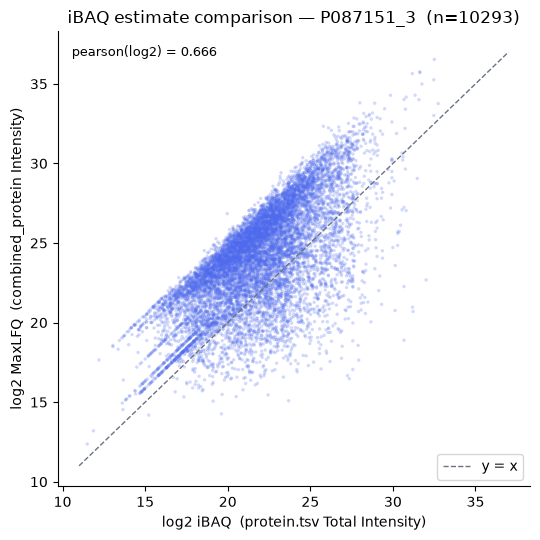

In [10]:
# Scatter: protein.tsv-based iBAQ vs combined_protein-based iBAQ (log-log), one tissue.
import matplotlib.pyplot as plt

t = ibaq.columns[2]
both = pd.DataFrame({"prot": ibaq[t], "pep": ibaq_pro[t]})
both = both[(both["prot"] > 0) & (both["pep"] > 0)].dropna()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(np.log2(both["prot"]), np.log2(both["pep"]), s=6, alpha=0.25, color="#4f6bed",
           edgecolors="none")
lo = np.floor(min(np.log2(both["prot"]).min(), np.log2(both["pep"]).min()))
hi = np.ceil(max(np.log2(both["prot"]).max(), np.log2(both["pep"]).max()))
ax.plot([lo, hi], [lo, hi], color="#6b7280", lw=1, ls="--", label="y = x")
ax.set_xlabel("log2 iBAQ  (protein.tsv Total Intensity)")
ax.set_ylabel("log2 MaxLFQ  (combined_protein Intensity)")
ax.set_title(f"iBAQ estimate comparison — {t}  (n={len(both)})")
r = agreement.loc[t, "pearson_log2"]
ax.text(0.03, 0.97, f"pearson(log2) = {r:.3f}", transform=ax.transAxes, va="top", fontsize=9)
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [11]:
# 4. TIC / median-of-totals normalization.
#    - sum each column
#    - median of those column sums
#    - normalization factor per column = column_sum / median
#    - DIVIDE each value in a column by its factor, so every column total
#      is scaled to the median total (equal column sums after normalization).
column_sums = ibaq.sum(axis=0)

median_sum = column_sums.median()

norm_factors = column_sums / median_sum

normalized = ibaq.divide(norm_factors, axis=1)

# Inspect the factors and the result.
print("Column sums:")
print(column_sums)
print(f"\nMedian of column sums: {median_sum}")
print("\nNormalization factors:")
print(norm_factors)

normalized

Column sums:
P087149_1     4.960936e+11
P087150_2     4.818844e+11
P087151_3     3.762651e+11
P087152_4     3.162079e+11
P087153_5     3.361715e+11
P087154_6     3.184078e+11
P087155_7     3.956438e+11
P087156_8     3.948405e+11
P087157_9     3.849290e+11
P087158_10    4.447322e+11
P087159_11    3.332324e+11
P087160_12    2.927054e+11
P087161_13    8.083525e+10
P087162_14    6.688697e+10
P087163_15    3.175780e+11
P087164_16    3.651405e+11
P087165_17    2.275782e+11
P087166_18    3.609279e+11
P087167_19    3.488072e+11
P087168_20    1.724518e+11
P087169_21    1.212976e+11
P087170_22    2.398309e+11
P087171_23    3.204447e+11
dtype: float64

Median of column sums: 333232432479.8504

Normalization factors:
P087149_1     1.488731
P087150_2     1.446091
P087151_3     1.129137
P087152_4     0.948911
P087153_5     1.008820
P087154_6     0.955513
P087155_7     1.187291
P087156_8     1.184880
P087157_9     1.155137
P087158_10    1.334601
P087159_11    1.000000
P087160_12    0.878382
P087161_1

,P087149_1,P087150_2,P087151_3,P087152_4,P087153_5,P087154_6,P087155_7,P087156_8,P087157_9,P087158_10,...,P087162_14,P087163_15,P087164_16,P087165_17,P087166_18,P087167_19,P087168_20,P087169_21,P087170_22,P087171_23
Protein,,,,,,,,,,,,,,,,,,,,,
GWHCAXY00000001_000001.1,2.212565e+05,NaN,NaN,NaN,6.706464e+04,NaN,1.752762e+05,4.797784e+05,6.291435e+04,6.568883e+05,...,NaN,NaN,2.405389e+05,NaN,1.536185e+05,1.031894e+06,6.589124e+04,NaN,NaN,NaN
GWHCAXY00000001_000005.1,0.000000e+00,NaN,NaN,NaN,1.187713e+05,NaN,1.039697e+05,NaN,NaN,8.595388e+04,...,NaN,NaN,NaN,NaN,NaN,2.773480e+05,NaN,NaN,NaN,NaN
GWHCAXY00000001_000006.1,8.928751e+06,1.862206e+07,1.757451e+07,1.530228e+07,5.020498e+06,4.802447e+05,2.115227e+07,3.691887e+06,9.046716e+06,1.831022e+07,...,9.060481e+05,9.887762e+06,1.203055e+07,2.592451e+06,4.767431e+06,2.150858e+06,3.755697e+06,1.128336e+06,2.570817e+05,1.982089e+07
GWHCAXY00000001_000010.1,0.000000e+00,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,0.000000e+00,...,NaN,NaN,NaN,NaN,1.672300e+06,3.071434e+06,NaN,NaN,1.093545e+06,NaN
GWHCAXY00000001_000013.1,7.472085e+06,6.959910e+06,7.854565e+06,1.738359e+07,9.192531e+06,2.870952e+07,1.314060e+07,6.618228e+06,6.264507e+06,5.882500e+06,...,1.325863e+07,6.486726e+07,6.178399e+07,4.354194e+06,7.814443e+06,4.264582e+06,2.264232e+06,1.528178e+05,1.464917e+06,5.209968e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sp|P62979|RS27A_HUMAN,2.769628e+08,2.439187e+08,1.764487e+08,1.111248e+08,2.364974e+08,8.040016e+07,2.863403e+08,2.416517e+08,1.008224e+08,1.587816e+08,...,6.469798e+07,1.102557e+08,1.020863e+08,1.601403e+08,2.616094e+08,3.732578e+08,1.446352e+08,1.505728e+08,1.438631e+08,1.231035e+08
sp|P68871|HBB_HUMAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.306485e+06,NaN,2.196246e+05,NaN,NaN,2.645558e+06,6.491498e+05,NaN,NaN
sp|P69905|HBA_HUMAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.084335e+06,NaN,NaN,NaN,NaN,3.873250e+05,NaN,NaN,NaN


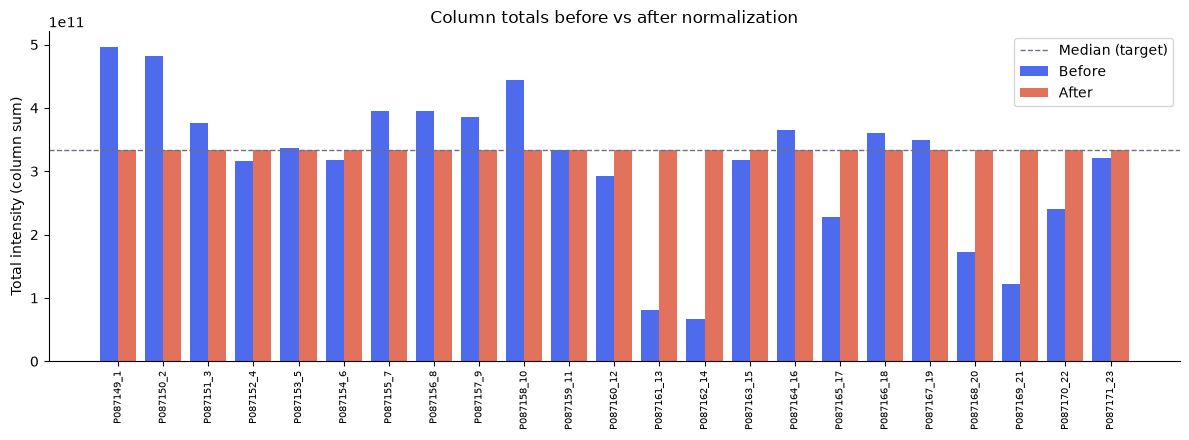

In [12]:
# Sanity check 1: column totals before vs after normalization.
# For median-of-totals normalization the "after" bars should be closer together.
import numpy as np
import matplotlib.pyplot as plt

samples = [c.replace(" Intensity", "") for c in ibaq.columns]
sums_before = ibaq.sum(axis=0).values
sums_after = normalized.sum(axis=0).values

x = np.arange(len(samples))
w = 0.4
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - w / 2, sums_before, w, label="Before", color="#4f6bed")
ax.bar(x + w / 2, sums_after, w, label="After", color="#e2725b")
ax.axhline(median_sum, color="#6b7280", lw=1, ls="--", label="Median (target)")
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=90, fontsize=7)
ax.set_ylabel("Total intensity (column sum)")
ax.set_title("Column totals before vs after normalization")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

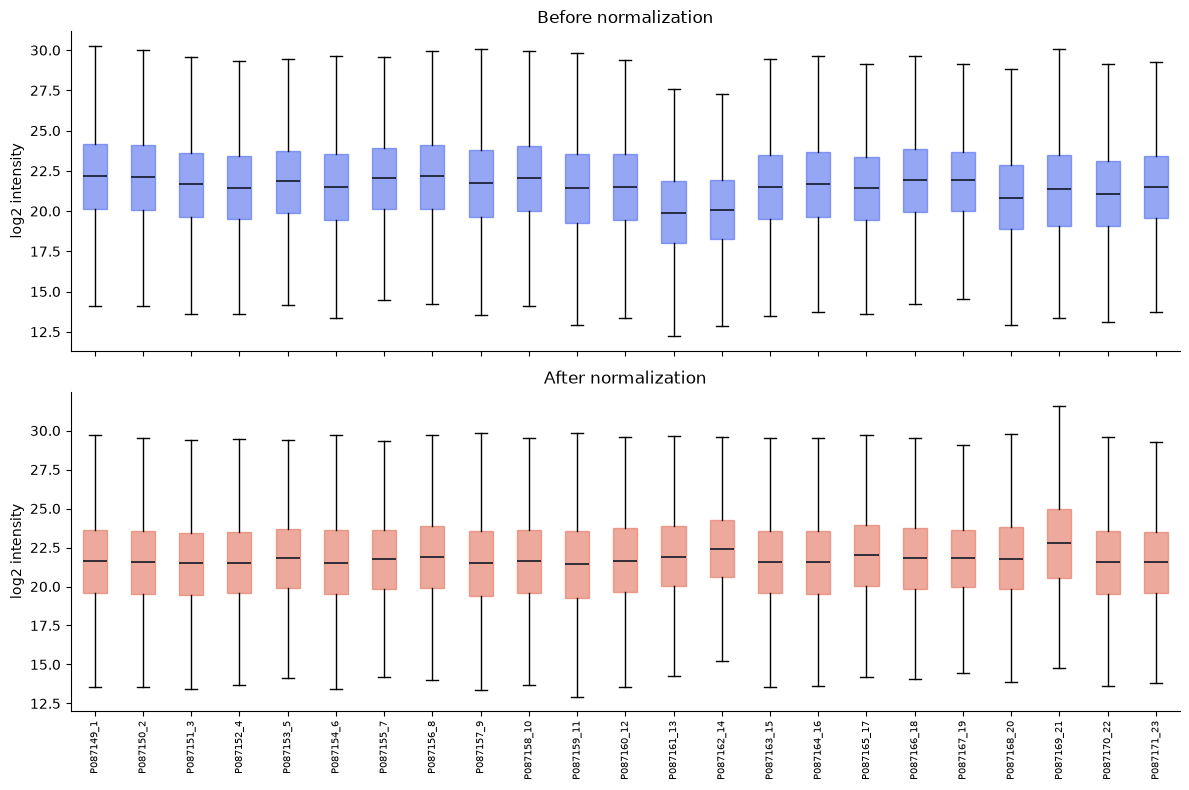

In [13]:
# Sanity check 2: per-sample log2 intensity distributions before vs after.
# Zeros are dropped (log undefined). Well-normalized samples have aligned medians.
def log2_nonzero(frame):
    return [np.log2(col[col > 0].values) for _, col in frame.items()]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, data, title, color in [
    (axes[0], log2_nonzero(ibaq), "Before normalization", "#4f6bed"),
    (axes[1], log2_nonzero(normalized), "After normalization", "#e2725b"),
]:
    bp = ax.boxplot(data, showfliers=False, patch_artist=True,
                    medianprops=dict(color="#111827", lw=1.2))
    for box in bp["boxes"]:
        box.set(facecolor=color, alpha=0.6, edgecolor=color)
    ax.set_ylabel("log2 intensity")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)

axes[1].set_xticks(np.arange(1, len(samples) + 1))
axes[1].set_xticklabels(samples, rotation=90, fontsize=7)
fig.tight_layout()
plt.show()

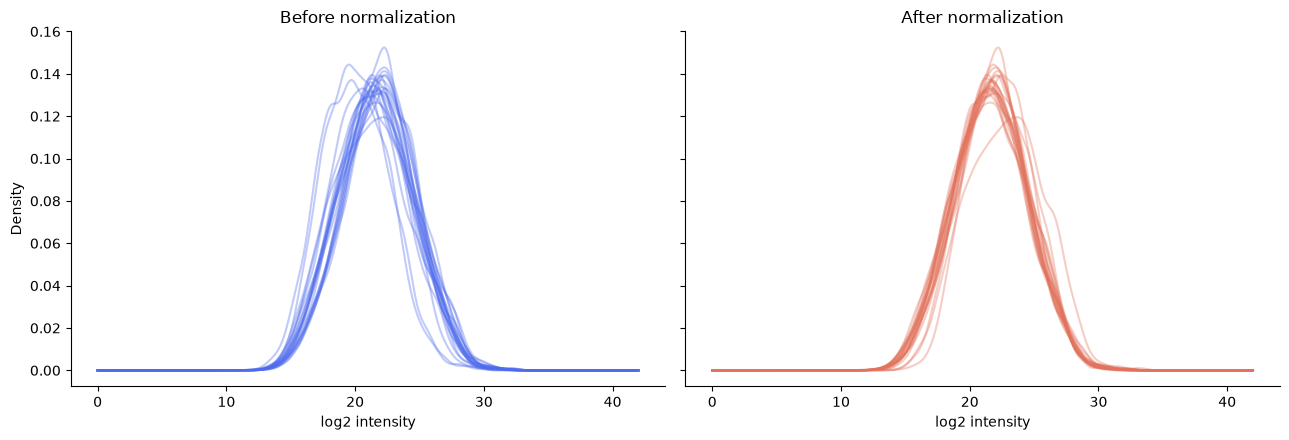

In [14]:
# Sanity check 3: per-sample log2 intensity density distributions, before vs after.
# One smooth KDE curve per sample. After normalization the curves should overlap
# more tightly. All curves share one hue: identity of the individual sample is not
# the point here, the alignment of the distributions is.
from scipy.stats import gaussian_kde

grid = np.linspace(0, 42, 400)

def kde_curves(frame):
    curves = []
    for _, col in frame.items():
        vals = np.log2(col[col > 0].values)
        curves.append(gaussian_kde(vals)(grid))
    return curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, frame, title, color in [
    (axes[0], ibaq, "Before normalization", "#4f6bed"),
    (axes[1], normalized, "After normalization", "#e2725b"),
]:
    for dens in kde_curves(frame):
        ax.plot(grid, dens, color=color, alpha=0.35)
    ax.set_xlabel("log2 intensity")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Density")
fig.tight_layout()
plt.show()

In [36]:
normalized

,P087149_1,P087150_2,P087151_3,P087152_4,P087153_5,P087154_6,P087155_7,P087156_8,P087157_9,P087158_10,...,P087162_14,P087163_15,P087164_16,P087165_17,P087166_18,P087167_19,P087168_20,P087169_21,P087170_22,P087171_23
Protein,,,,,,,,,,,,,,,,,,,,,
GWHCAXY00000001_000001.1,2.212565e+05,NaN,NaN,NaN,6.706464e+04,NaN,1.752762e+05,4.797784e+05,6.291435e+04,6.568883e+05,...,NaN,NaN,2.405389e+05,NaN,1.536185e+05,1.031894e+06,6.589124e+04,NaN,NaN,NaN
GWHCAXY00000001_000005.1,0.000000e+00,NaN,NaN,NaN,1.187713e+05,NaN,1.039697e+05,NaN,NaN,8.595388e+04,...,NaN,NaN,NaN,NaN,NaN,2.773480e+05,NaN,NaN,NaN,NaN
GWHCAXY00000001_000006.1,8.928751e+06,1.862206e+07,1.757451e+07,1.530228e+07,5.020498e+06,4.802447e+05,2.115227e+07,3.691887e+06,9.046716e+06,1.831022e+07,...,9.060481e+05,9.887762e+06,1.203055e+07,2.592451e+06,4.767431e+06,2.150858e+06,3.755697e+06,1.128336e+06,2.570817e+05,1.982089e+07
GWHCAXY00000001_000010.1,0.000000e+00,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,0.000000e+00,...,NaN,NaN,NaN,NaN,1.672300e+06,3.071434e+06,NaN,NaN,1.093545e+06,NaN
GWHCAXY00000001_000013.1,7.472085e+06,6.959910e+06,7.854565e+06,1.738359e+07,9.192531e+06,2.870952e+07,1.314060e+07,6.618228e+06,6.264507e+06,5.882500e+06,...,1.325863e+07,6.486726e+07,6.178399e+07,4.354194e+06,7.814443e+06,4.264582e+06,2.264232e+06,1.528178e+05,1.464917e+06,5.209968e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sp|P62979|RS27A_HUMAN,2.769628e+08,2.439187e+08,1.764487e+08,1.111248e+08,2.364974e+08,8.040016e+07,2.863403e+08,2.416517e+08,1.008224e+08,1.587816e+08,...,6.469798e+07,1.102557e+08,1.020863e+08,1.601403e+08,2.616094e+08,3.732578e+08,1.446352e+08,1.505728e+08,1.438631e+08,1.231035e+08
sp|P68871|HBB_HUMAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.306485e+06,NaN,2.196246e+05,NaN,NaN,2.645558e+06,6.491498e+05,NaN,NaN
sp|P69905|HBA_HUMAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.084335e+06,NaN,NaN,NaN,NaN,3.873250e+05,NaN,NaN,NaN


In [42]:
median_of_median = normalized.median(axis=0).median()
norm_factors = normalized.median(axis=0) / median_of_median
normalized_median = normalized.divide(norm_factors, axis=1)

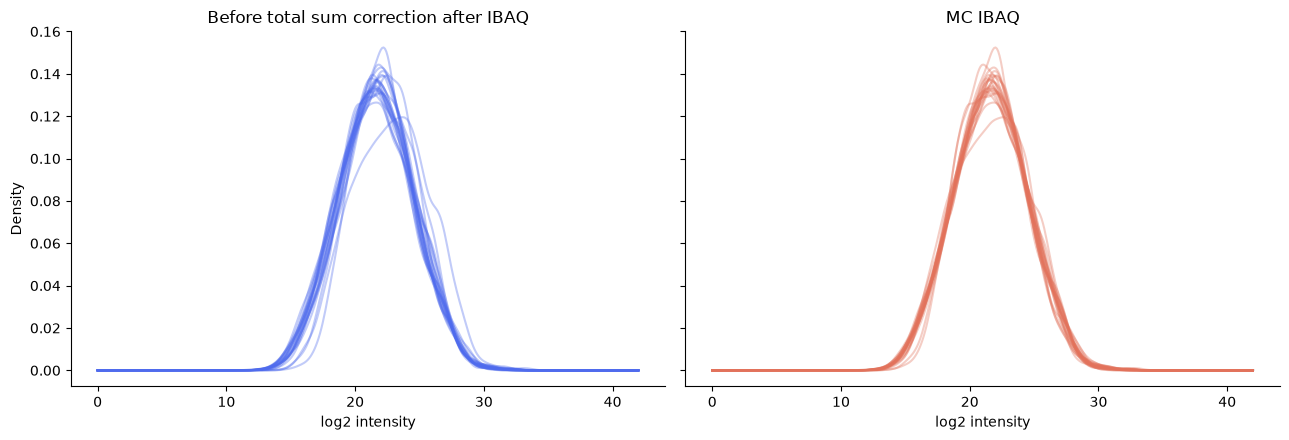

In [44]:
# Sanity check 3: per-sample log2 intensity density distributions, before vs after.
# One smooth KDE curve per sample. After normalization the curves should overlap
# more tightly. All curves share one hue: identity of the individual sample is not
# the point here, the alignment of the distributions is.
from scipy.stats import gaussian_kde

grid = np.linspace(0, 42, 400)

def kde_curves(frame):
    curves = []
    for _, col in frame.items():
        vals = np.log2(col[col > 0].values)
        curves.append(gaussian_kde(vals)(grid))
    return curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, frame, title, color in [
    (axes[0], normalized, "Before total sum correction after IBAQ", "#4f6bed"),
    (axes[1], normalized_median, "MC IBAQ", "#e2725b"),
]:
    for dens in kde_curves(frame):
        ax.plot(grid, dens, color=color, alpha=0.35)
    ax.set_xlabel("log2 intensity")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Density")
fig.tight_layout()
plt.show()